In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

In [63]:
data_path = "../datasets/hr_raw.csv"
df_raw = pd.read_csv(data_path)

print(f"Rows: {len(df_raw):,}, Columns: {df_raw.shape[1]}")
display(df_raw.head())
print("\nData types:")
print(df_raw.dtypes)

missing = df_raw.isna().sum().sort_values(ascending=False)
missing_nonzero = missing[missing > 0]
if not missing_nonzero.empty:
    print("\nMissing values (non-zero):")
    display(missing_nonzero)
else:
    print("\nNo missing values detected.")

Rows: 2,000,000, Columns: 15


,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level
0,EMP0000001,Heinz-Georg Eimer,Sales,Business Development,2023-01-31,Satisfactory,8,Active,On-site,92992.0,2023,Germany,Munich,32,Mid
1,EMP0000002,Maartje van den Nuwenhuysen-Geertsen,HR,HR Manager,2008-11-07,Good,11,Active,On-site,112318.0,2008,Netherlands,Eindhoven,43,Senior
2,EMP0000003,Sara Sureda Figueroa,HR,Talent Specialist,2016-03-19,Needs Improvement,15,Active,On-site,111121.0,2016,Spain,Seville,43,Senior
3,EMP0000004,Luce Sanchez,Operations,Operations Director,2024-04-03,Good,1,Active,Hybrid,49012.0,2024,France,Marseille,23,Junior
4,EMP0000005,William Jennings,Sales,Regional Lead,2024-11-17,Good,2,Active,On-site,57553.0,2024,United Kingdom,Edinburgh,31,Junior



Data types:
Employee_ID            object
Full_Name              object
Department             object
Job_Title              object
Hire_Date              object
Performance_Rating     object
Experience_Years        int64
Status                 object
Work_Mode              object
Salary                float64
Year                    int64
Country                object
City                   object
Age                     int64
Job_Level              object
dtype: object

Missing values (non-zero):


Performance_Rating    3333
dtype: int64

In [64]:
df_raw['Hire_Date'] = pd.to_datetime(df_raw['Hire_Date'], errors='coerce')

In [65]:
before = len(df_raw)
df_raw = df_raw.drop_duplicates()
after = len(df_raw)
print(f"Removed {before - after:,} duplicate rows; remaining {after:,} rows.")

Removed 0 duplicate rows; remaining 2,000,000 rows.


In [66]:
df_raw.describe().style.format("{:.2f}")

,Hire_Date,Experience_Years,Salary,Year,Age
count,2000000.00,2000000.00,2000000.00,2000000.00,2000000.00
mean,.2f,6.27,89948.36,2020.04,31.41
min,.2f,-5.00,-99932.00,2008.00,21.00
25%,.2f,2.00,53710.00,2017.00,27.00
50%,.2f,5.00,80829.00,2022.00,30.00
75%,.2f,8.00,104180.00,2024.00,35.00
max,.2f,30.00,322107.00,2026.00,66.00
std,nan,5.66,46894.32,4.99,6.74


In [67]:
df_raw['Performance_Rating'].value_counts(normalize=True)

Performance_Rating
Good                 0.500318
Satisfactory         0.279932
Excellent            0.149671
Needs Improvement    0.070079
Name: proportion, dtype: float64

In [68]:
df_raw['Performance_Rating'] = df_raw['Performance_Rating'].fillna('Not Rated')

missing_after = df_raw['Performance_Rating'].isna().sum()
print(f"Remaining missing in Performance_Rating: {missing_after}")
print(df_raw['Performance_Rating'].value_counts().head())

Remaining missing in Performance_Rating: 0
Performance_Rating
Good                 998968
Satisfactory         558931
Excellent            298844
Needs Improvement    139924
Not Rated              3333
Name: count, dtype: int64


In [69]:
df_raw = df_raw[df_raw['Experience_Years'] >= 0]

salary_invalid = (df_raw['Salary'] <= 0) | df_raw['Salary'].isna()

med_level_dept = df_raw.groupby(['Job_Level', 'Department'])['Salary'].median()
med_level = df_raw.groupby('Job_Level')['Salary'].median()
med_dept = df_raw.groupby('Department')['Salary'].median()
salary_global = df_raw['Salary'].median()

def _infer_salary(row):
    val = med_level_dept.get((row['Job_Level'], row['Department']), np.nan)
    if pd.isna(val):
        val = med_level.get(row['Job_Level'], np.nan)
    if pd.isna(val):
        val = med_dept.get(row['Department'], np.nan)
    if pd.isna(val):
        val = salary_global
    return val

imputed = df_raw.loc[salary_invalid].apply(_infer_salary, axis=1)
df_raw.loc[salary_invalid, 'Salary'] = imputed

print(f"Imputed {salary_invalid.sum():,} salary values using median fallback (level+dept → level → dept → global).")

Imputed 3,333 salary values using median fallback (level+dept → level → dept → global).


In [70]:
df_raw.describe().style.format("{:.2f}")

,Hire_Date,Experience_Years,Salary,Year,Age
count,1997579.00,1997579.00,1997579.00,1997579.00,1997579.00
mean,.2f,6.29,90180.65,2020.04,31.41
min,.2f,0.00,33308.00,2008.00,21.00
25%,.2f,2.00,53780.00,2017.00,27.00
50%,.2f,5.00,80905.00,2022.00,30.00
75%,.2f,8.00,104270.00,2024.00,35.00
max,.2f,30.00,322107.00,2026.00,66.00
std,nan,5.65,46569.04,4.99,6.74


In [71]:
zero_experience = df_raw[df_raw['Experience_Years'] == 0]
print(f"Employees with zero experience: {len(zero_experience)}")

Employees with zero experience: 189322


In [72]:
zero_experience.head(10)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level
6,EMP0000007,Abdul Hopkins,Operations,Operations Manager,2025-02-01,Excellent,0,Active,On-site,44048.0,2025,United Kingdom,Edinburgh,26,Junior
10,EMP0000011,Mrs Lauren Green,Sales,Business Development,2024-10-24,Needs Improvement,0,Active,On-site,55615.0,2024,United Kingdom,Edinburgh,24,Junior
14,EMP0000015,Nigel Edwards,Sales,Sales Manager,2023-11-18,Good,0,Resigned,On-site,44369.0,2023,United Kingdom,Leeds,24,Junior
15,EMP0000016,Abdul Burton-Patterson,Operations,Operations Manager,2021-06-27,Good,0,Resigned,Hybrid,46388.0,2021,United Kingdom,London,27,Junior
37,EMP0000038,Bernard Wilkinson-Simpson,Operations,Logistics,2021-03-18,Good,0,Active,On-site,49317.0,2021,United Kingdom,Leeds,25,Junior
38,EMP0000039,Morena Tomas Lastra,Finance,CFO,2023-07-20,Satisfactory,0,Active,On-site,62268.0,2023,Spain,Bilbao,24,Junior
49,EMP0000050,Ms Lindsey Rees,Sales,Business Development,2024-09-01,Satisfactory,0,Active,Remote,53789.0,2024,United Kingdom,Edinburgh,24,Junior
68,EMP0000069,Aaron Harrison,IT,System Admin,2013-08-08,Good,0,Active,On-site,57270.0,2013,United Kingdom,Edinburgh,28,Junior
69,EMP0000070,Anita Bondyra,Finance,Accountant,2025-06-30,Good,0,Active,Remote,53255.0,2025,Poland,Krakow,23,Junior
70,EMP0000071,Ciriaco Morillo Moles,HR,HR Director,2021-06-21,Excellent,0,Resigned,Remote,42964.0,2021,Spain,Seville,23,Junior


In [73]:
df_raw.dtypes

Employee_ID                   object
Full_Name                     object
Department                    object
Job_Title                     object
Hire_Date             datetime64[ns]
Performance_Rating            object
Experience_Years               int64
Status                        object
Work_Mode                     object
Salary                       float64
Year                           int64
Country                       object
City                          object
Age                            int64
Job_Level                     object
dtype: object

In [74]:
df_raw['Hire_Date'].describe()

count                          1997579
mean     2020-07-10 22:21:15.724665088
min                2008-03-24 00:00:00
25%                2017-11-29 00:00:00
50%                2022-01-25 00:00:00
75%                2024-07-02 00:00:00
max                2026-03-25 00:00:00
Name: Hire_Date, dtype: object

In [75]:
df_raw['Hire_Year'] = df_raw['Hire_Date'].dt.year

mismatch = df_raw[df_raw['Hire_Year'] != df_raw['Year']]
len(mismatch)

0

**The workforce is relatively new, with most employees hired after 2020.**

In [76]:
today = pd.Timestamp.today()

df_raw['Tenure_Years'] = (today - df_raw['Hire_Date']).dt.days / 365

In [77]:
tenure_stats = df_raw['Tenure_Years'].describe()
display(tenure_stats.to_frame(name='Tenure_Years').style.format("{:.2f}"))

,Tenure_Years
count,1997579.00
mean,5.72
std,5.02
min,0.01
25%,1.74
50%,4.18
75%,8.34
max,18.03


In [91]:
num_cols = ['Age', 'Salary', 'Experience_Years', 'Tenure_Years']

Saved cleaned dataset to ../datasets/hr_clean.csv


In [79]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    return outliers, lower, upper

In [80]:
outlier_summary = {}

for col in num_cols:
    outliers, lower, upper = detect_outliers_iqr(df_raw, col)
    
    outlier_summary[col] = {
        'count': len(outliers),
        'lower_bound': lower,
        'upper_bound': upper
    }

outlier_summary

{'Age': {'count': 68603,
  'lower_bound': np.float64(15.0),
  'upper_bound': np.float64(47.0)},
 'Salary': {'count': 100067,
  'lower_bound': np.float64(-21955.0),
  'upper_bound': np.float64(180005.0)},
 'Experience_Years': {'count': 87049,
  'lower_bound': np.float64(-7.0),
  'upper_bound': np.float64(17.0)},
 'Tenure_Years': {'count': 0,
  'lower_bound': np.float64(-8.149315068493152),
  'upper_bound': np.float64(18.228767123287675)}}

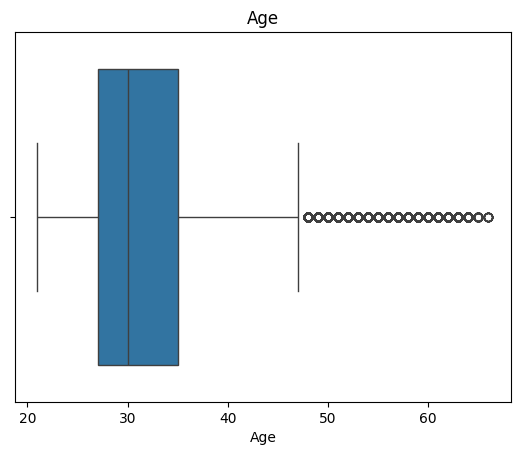

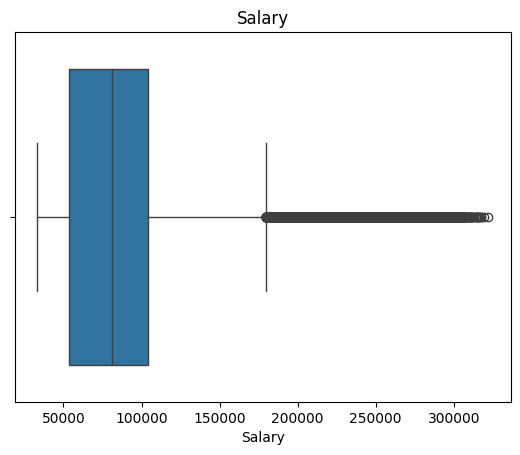

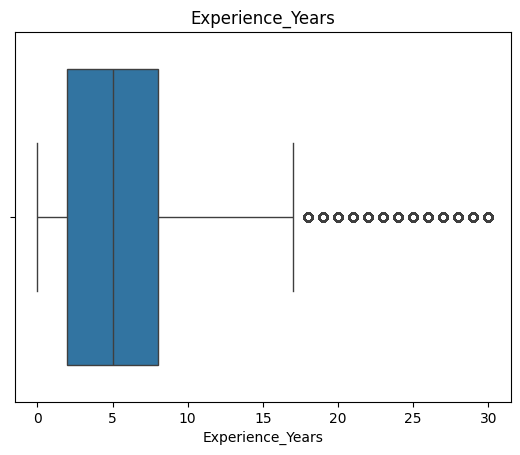

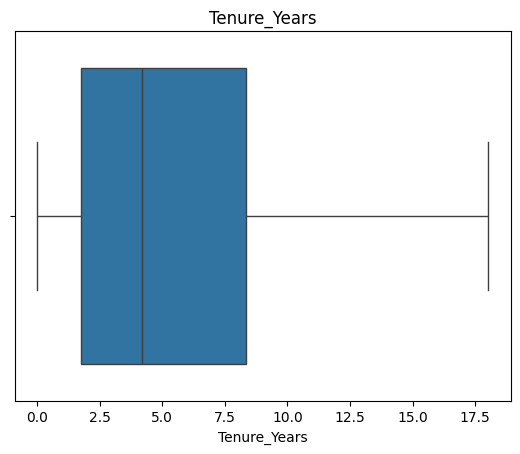

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df_raw[col])
    plt.title(col)
    plt.show()

**Outliers in this case will be kept. Outliers that are resulted from the IQR method higher than the upper bounds in this case are valid and are not true outliers.**

In [82]:
cat_cols = [
    'Department', 'Job_Title', 'Performance_Rating',
    'Status', 'Work_Mode', 'Country', 'City', 'Job_Level'
]

In [83]:
for col in cat_cols:
    print(f"\n{col}")
    print(df_raw[col].value_counts().head(10))


Department
Department
Sales         599933
IT            498687
Operations    400141
Finance       299594
HR            199224
Name: count, dtype: int64

Job_Title
Job_Title
Sales Manager           120452
Sales Executive         120202
Sales Director          119838
Regional Lead           119745
Business Development    119696
IT Manager              100010
System Admin             99953
DevOps Engineer          99768
Data Engineer            99622
Software Developer       99334
Name: count, dtype: int64

Performance_Rating
Performance_Rating
Good                 997770
Satisfactory         558248
Excellent            298493
Needs Improvement    139735
Not Rated              3333
Name: count, dtype: int64

Status
Status
Active        1791415
Resigned       159820
Terminated      45891
Retired           453
Name: count, dtype: int64

Work_Mode
Work_Mode
On-site    1098030
Remote      549440
Hybrid      350109
Name: count, dtype: int64

Country
Country
United Kingdom    499066
Germany  

In [84]:
df_raw['Attrition'] = df_raw['Status'].apply(
    lambda x: 0 if x == 'Active' else 1
)

In [85]:
df = df_raw.copy()

In [86]:
df.head()

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level,Hire_Year,Tenure_Years,Attrition
0,EMP0000001,Heinz-Georg Eimer,Sales,Business Development,2023-01-31,Satisfactory,8,Active,On-site,92992.0,2023,Germany,Munich,32,Mid,2023,3.161644,0
1,EMP0000002,Maartje van den Nuwenhuysen-Geertsen,HR,HR Manager,2008-11-07,Good,11,Active,On-site,112318.0,2008,Netherlands,Eindhoven,43,Senior,2008,17.402740,0
2,EMP0000003,Sara Sureda Figueroa,HR,Talent Specialist,2016-03-19,Needs Improvement,15,Active,On-site,111121.0,2016,Spain,Seville,43,Senior,2016,10.035616,0
3,EMP0000004,Luce Sanchez,Operations,Operations Director,2024-04-03,Good,1,Active,Hybrid,49012.0,2024,France,Marseille,23,Junior,2024,1.989041,0
4,EMP0000005,William Jennings,Sales,Regional Lead,2024-11-17,Good,2,Active,On-site,57553.0,2024,United Kingdom,Edinburgh,31,Junior,2024,1.364384,0


In [87]:
df["Attrition"].value_counts()

Attrition
0    1791415
1     206164
Name: count, dtype: int64

In [90]:
df.describe().style.format("{:.2f}")

,Hire_Date,Experience_Years,Salary,Year,Age,Hire_Year,Tenure_Years,Attrition
count,1997579.00,1997579.00,1997579.00,1997579.00,1997579.00,1997579.00,1997579.00,1997579.00
mean,.2f,6.29,90180.65,2020.04,31.41,2020.04,5.72,0.10
min,.2f,0.00,33308.00,2008.00,21.00,2008.00,0.01,0.00
25%,.2f,2.00,53780.00,2017.00,27.00,2017.00,1.74,0.00
50%,.2f,5.00,80905.00,2022.00,30.00,2022.00,4.18,0.00
75%,.2f,8.00,104270.00,2024.00,35.00,2024.00,8.34,0.00
max,.2f,30.00,322107.00,2026.00,66.00,2026.00,18.03,1.00
std,nan,5.65,46569.04,4.99,6.74,4.99,5.02,0.30


In [92]:
output_path = "../datasets/hr_data_clean.csv"
df_raw.to_csv(output_path, index=False)
print(f"Saved cleaned dataset to {output_path}")

Saved cleaned dataset to ../datasets/hr_data_clean.csv
